# Data Preparation for Indian Hinglish Turn Detection

**Task:** predict whether an utterance is complete (`1`) or incomplete (`0`) from audio.

This notebook turns data-preparation choices into executable evidence. It focuses on the costly voice-agent failure: declaring a turn complete while the speaker is only pausing, using a filler, or code-switching.

**Success criteria**

- Every statistic is computed from the prepared local sample, not invented.
- Publisher labels remain authoritative; augmentation does not silently flip them.
- Validation and test stay clean; stochastic transforms apply to training only.
- Claims distinguish Hindi-tagged proxies from verified Hinglish, which the source schema does not provide.

## Reproducibility setup

Run from repository root after:

```powershell
uv sync
uv run python scripts/prepare_data.py
```

Remote streaming is optional and disabled by default. The notebook uses decoded local manifests so waveform statistics and examples are reproducible offline.

In [1]:
from pathlib import Path
import random
import sys
import warnings

warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message="The `hop_length` parameter is deprecated.*")
warnings.filterwarnings("ignore", message="The `n_fft` parameter is deprecated.*")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import soundfile as sf

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError("Run notebook from repository root or notebooks/ directory")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from configs import config as cfg
from src.dataset import (
    AugmentConfig,
    FillerBank,
    add_background_noise,
    build_hard_negative_indices,
    inject_filler,
    insert_silence,
    load_noise_bank,
    measure_pause_features,
    pitch_shift,
    speed_perturb,
    volume_perturb,
)

SEED = 42
DATASET_ID = "pipecat-ai/smart-turn-data-v3.2-train"
USE_REMOTE_STREAM = False
random.seed(SEED)
np.random.seed(SEED)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"project_root={PROJECT_ROOT.name}")
print(f"dataset={DATASET_ID}; seed={SEED}")

project_root=hinglish-turn-detection
dataset=pipecat-ai/smart-turn-data-v3.2-train; seed=42


## Plan and hypotheses

1. Audit schema, balance, duration, language, filler availability, and synthetic-audio share.
2. Measure low-energy pauses without pretending they are linguistic ground truth.
3. Define labels before augmentation.
4. Test targeted transformations and quantify how they alter one waveform.
5. Mine examples that break duration shortcuts.
6. verify split balance and ID separation.

**Hypotheses:** silence and filler robustness should improve hard-case coverage, but overly long pauses or class-correlated filler synthesis may increase false completions. All choices therefore require ablation rather than intuition alone.

## 1. Dataset loading and basic exploration

In [2]:
if USE_REMOTE_STREAM:
    from datasets import load_dataset

    stream = load_dataset(DATASET_ID, split="train", streaming=True)
    first_remote_row = next(iter(stream))
    print("Remote schema:", sorted(first_remote_row))
else:
    print("Remote stream disabled. Using local artifacts from scripts/prepare_data.py.")

paths = {
    "source_train": cfg.SUBSET_DIR / "train_meta_raw.parquet",
    "train": cfg.SUBSET_DIR / "train_split.parquet",
    "validation": cfg.SUBSET_DIR / "val_split.parquet",
    "test": cfg.SUBSET_DIR / "test_split.parquet",
}
missing = [str(path) for path in paths.values() if not path.is_file()]
if missing:
    raise FileNotFoundError(
        "Missing prepared manifests. Run `uv run python scripts/prepare_data.py`: "
        + ", ".join(missing)
    )

frames = {name: pl.read_parquet(path) for name, path in paths.items()}
source_train = frames["source_train"]
train_df = frames["train"]
val_df = frames["validation"]
test_df = frames["test"]

print("Rows:", {name: frame.height for name, frame in frames.items()})
print("Columns:", source_train.columns)
source_train.select(
    "id", "language", "endpoint_bool", "duration_s", "midfiller", "endfiller", "synthetic"
).head(5)

Remote stream disabled. Using local artifacts from scripts/prepare_data.py.
Rows: {'source_train': 7517, 'train': 6613, 'validation': 904, 'test': 4890}
Columns: ['id', 'language', 'endpoint_bool', 'midfiller', 'endfiller', 'synthetic', 'source_dataset', 'duration_s', 'orig_sample_rate', 'path', 'is_augmented', 'augment_type', 'midfiller_annotation_known', 'endfiller_annotation_known']


id,language,endpoint_bool,duration_s,midfiller,endfiller,synthetic
str,str,bool,f64,bool,bool,bool
"""00006fe3-5331-4db2-b30e-65affe…","""zho""",true,6.16,true,false,true
"""000081dd-b6dc-420c-be34-57bd82…","""eng""",true,12.965188,false,false,false
"""0000abee-a101-4a2f-bdb5-aecae1…","""vie""",false,5.04,false,true,true
"""0001e47c-ff52-46ca-8368-380f2a…","""fin""",false,6.0,true,false,true
"""00021667-9e19-4e6b-8f5c-af600d…","""eng""",false,5.509,false,false,false


## 2. Detailed statistics

Three scopes must stay separate:

- Publisher metadata describes full repository size and schema.
- Dataset Viewer statistics may cover only a partial scan.
- Cells below describe the decoded local sample and can inspect waveforms.

label,rows,percent
str,i64,f64
"""incomplete (0)""",3784,50.34
"""complete (1)""",3733,49.66


statistic,seconds
str,f64
"""mean""",7.84
"""median""",7.2
"""p10""",3.56
"""p90""",13.12
"""minimum""",0.36
"""maximum""",32.6


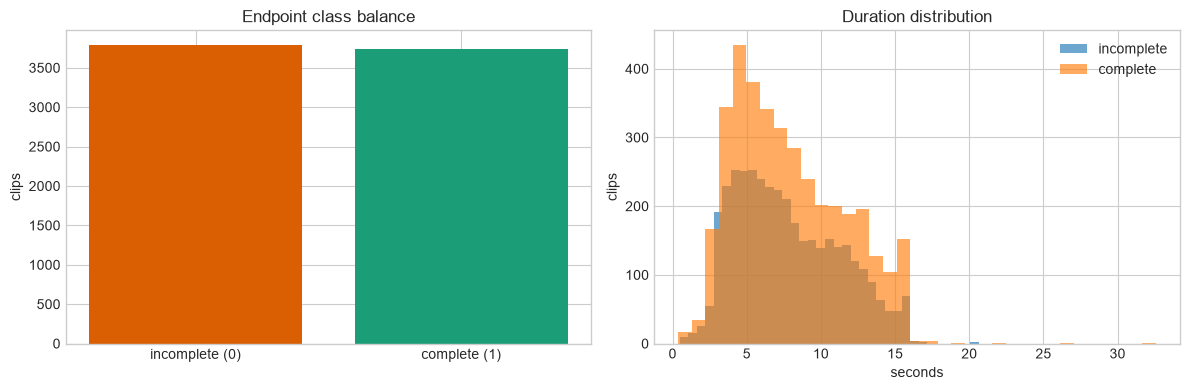

In [3]:
labels = source_train["endpoint_bool"].to_numpy()
durations = source_train["duration_s"].to_numpy()

class_table = pl.DataFrame(
    {
        "label": ["incomplete (0)", "complete (1)"],
        "rows": [int((~labels).sum()), int(labels.sum())],
    }
).with_columns((100 * pl.col("rows") / source_train.height).round(2).alias("percent"))

duration_table = pl.DataFrame(
    {
        "statistic": ["mean", "median", "p10", "p90", "minimum", "maximum"],
        "seconds": [
            durations.mean(),
            np.median(durations),
            np.percentile(durations, 10),
            np.percentile(durations, 90),
            durations.min(),
            durations.max(),
        ],
    }
).with_columns(pl.col("seconds").round(2))

display(class_table)
display(duration_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(class_table["label"], class_table["rows"], color=["#d95f02", "#1b9e77"])
axes[0].set(title="Endpoint class balance", ylabel="clips")
axes[1].hist(durations[~labels], bins=35, alpha=0.65, label="incomplete")
axes[1].hist(durations[labels], bins=35, alpha=0.65, label="complete")
axes[1].set(title="Duration distribution", xlabel="seconds", ylabel="clips")
axes[1].legend()
plt.tight_layout()
plt.show()

In [4]:
language_table = (
    source_train.group_by("language")
    .agg(
        pl.len().alias("rows"),
        pl.col("endpoint_bool").sum().alias("complete"),
    )
    .with_columns((pl.col("rows") - pl.col("complete")).alias("incomplete"))
    .sort("rows", descending=True)
)
metadata_signals = pl.DataFrame(
    {
        "signal": ["midfiller=True", "endfiller=True", "synthetic", "recorded/non-synthetic"],
        "rows": [
            int(source_train["midfiller"].sum()),
            int(source_train["endfiller"].sum()),
            int(source_train["synthetic"].sum()),
            int((~source_train["synthetic"]).sum()),
        ],
    }
)

display(language_table.head(10))
display(metadata_signals)
print("Original sample rates:", source_train["orig_sample_rate"].unique().to_list())
print("Duplicate IDs:", source_train.height - source_train["id"].n_unique())

language,rows,complete,incomplete
str,u32,u32,u32
"""eng""",3646,1818,1828
"""hin""",721,346,375
"""zho""",150,70,80
"""vie""",150,73,77
"""ind""",150,70,80
"""mar""",150,73,77
"""dan""",150,83,67
"""nor""",150,76,74
"""ukr""",150,83,67


signal,rows
str,i64
"""midfiller=True""",2445
"""endfiller=True""",1545
"""synthetic""",5060
"""recorded/non-synthetic""",2457


Original sample rates: [16000]
Duplicate IDs: 0


### Silence analysis

The proxy uses 20 ms RMS frames, 10 ms hops, an RMS threshold of 0.01 (-40 dBFS), and a minimum 100 ms low-energy run. It is reproducible, but not a ground-truth VAD or linguistic pause annotation. Quiet microphones and background noise can change membership.

measure,all_clips_pct,incomplete_pct,complete_pct
str,f64,f64,f64
"""mean low-energy share""",17.1,16.8,17.4
"""any pause""",69.9,70.0,69.8
"""internal pause""",63.9,65.7,62.1
"""trailing pause""",45.4,42.3,48.5


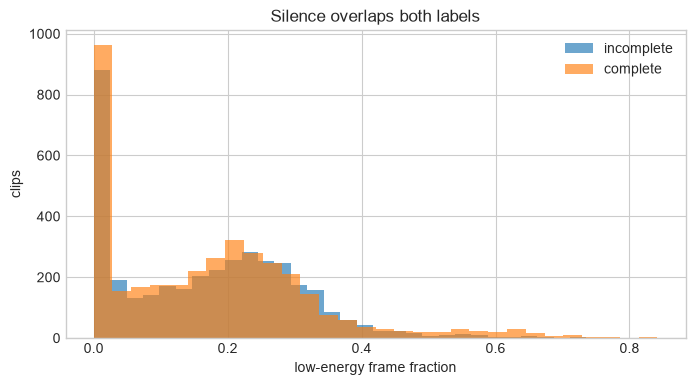

In [5]:
pause_records = []
for row in source_train.iter_rows(named=True):
    waveform, sample_rate = sf.read(PROJECT_ROOT / row["path"], dtype="float32")
    pause_records.append(
        {
            "endpoint_bool": row["endpoint_bool"],
            **measure_pause_features(waveform, sample_rate),
        }
    )

pause_df = pl.DataFrame(pause_records)
pause_summary = pl.DataFrame(
    {
        "measure": ["mean low-energy share", "any pause", "internal pause", "trailing pause"],
        "all_clips_pct": [
            100 * pause_df["low_energy_fraction"].mean(),
            100 * pause_df["any_pause"].mean(),
            100 * pause_df["internal_pause"].mean(),
            100 * pause_df["trailing_pause"].mean(),
        ],
        "incomplete_pct": [
            100 * pause_df.filter(~pl.col("endpoint_bool"))["low_energy_fraction"].mean(),
            100 * pause_df.filter(~pl.col("endpoint_bool"))["any_pause"].mean(),
            100 * pause_df.filter(~pl.col("endpoint_bool"))["internal_pause"].mean(),
            100 * pause_df.filter(~pl.col("endpoint_bool"))["trailing_pause"].mean(),
        ],
        "complete_pct": [
            100 * pause_df.filter(pl.col("endpoint_bool"))["low_energy_fraction"].mean(),
            100 * pause_df.filter(pl.col("endpoint_bool"))["any_pause"].mean(),
            100 * pause_df.filter(pl.col("endpoint_bool"))["internal_pause"].mean(),
            100 * pause_df.filter(pl.col("endpoint_bool"))["trailing_pause"].mean(),
        ],
    }
).with_columns(pl.exclude("measure").round(1))

display(pause_summary)
plt.figure(figsize=(8, 4))
plt.hist(
    pause_df.filter(~pl.col("endpoint_bool"))["low_energy_fraction"].to_numpy(),
    bins=30,
    alpha=0.65,
    label="incomplete",
)
plt.hist(
    pause_df.filter(pl.col("endpoint_bool"))["low_energy_fraction"].to_numpy(),
    bins=30,
    alpha=0.65,
    label="complete",
)
plt.xlabel("low-energy frame fraction")
plt.ylabel("clips")
plt.title("Silence overlaps both labels")
plt.legend()
plt.show()

## 3. Hinglish-specific challenges

- **Fillers are ambiguous:** “um” and “matlab” often signal continuation; “bas,” “haan,” or “wait” can be complete pragmatic turns.
- **Code-switching is unobservable in metadata:** one language tag cannot identify a Hindi clause containing English discourse markers. `spoken_text` is null.
- **Pauses are not labels:** breath, hesitation, word search, final silence, and network delay may have similar low-energy regions.
- **Prosody matters:** rising pitch, stretched final syllables, pace, and energy may signal continuation. Strong pitch/time transforms could erase that evidence.
- **Synthetic-domain gap:** TTS voices and clean splice timing may become shortcuts that do not transfer to human conversation.
- **Asymmetric cost:** false complete interrupts the user; false incomplete usually adds delay. Aggregate accuracy hides this difference.

Therefore this notebook uses Hindi, filler, and pause metadata as analysis slices—not as proof of a real Hinglish benchmark.

## 4. Label definition and re-labeling rules

| Source value | Model label | Meaning |
| --- | ---: | --- |
| `endpoint_bool=False` | 0 | incomplete; keep listening |
| `endpoint_bool=True` | 1 | complete; system may respond |

**Rules**

1. Publisher endpoint label is authoritative.
2. Silence, duration, language, and filler presence never override it automatically.
3. Nullable filler annotations preserve an `*_annotation_known` flag; unknown does not become confirmed absence.
4. Default filler injection is internal and label-preserving in both classes.
5. End-appended fillers that truncate speech are weak-label synthesis and are excluded from the default training path.
6. Contradictory high-loss examples should enter manual review, not silent automatic relabeling.

In [6]:
label_audit = pl.DataFrame(
    {
        "check": [
            "non-null endpoint labels",
            "binary endpoint labels",
            "mid-filler provenance column",
            "end-filler provenance column",
        ],
        "passed": [
            source_train["endpoint_bool"].null_count() == 0,
            set(source_train["endpoint_bool"].unique().to_list()) <= {False, True},
            "midfiller_annotation_known" in source_train.columns,
            "endfiller_annotation_known" in source_train.columns,
        ],
    }
)
display(label_audit)
assert label_audit["passed"].all()

check,passed
str,bool
"""non-null endpoint labels""",true
"""binary endpoint labels""",true
"""mid-filler provenance column""",true
"""end-filler provenance column""",true


## 5. Targeted augmentation design

Augmentation changes training acoustics, not validation/test labels. Each transform addresses a named failure mode and has a bounded range to protect endpoint prosody.

In [7]:
policy = AugmentConfig(
    enabled=True,
    p_silence=0.30,
    p_speed=0.30,
    p_pitch=0.20,
    p_noise=0.20,
    p_volume=0.30,
    p_filler=0.35,
    silence_ms_range=(100, 800),
)
policy

AugmentConfig(enabled=True, p_silence=0.3, p_speed=0.3, p_pitch=0.2, p_noise=0.2, p_volume=0.3, p_filler=0.35, silence_ms_range=(100, 800))

In [8]:
example_candidates = train_df.filter(
    (pl.col("language") == "hin")
    & ~pl.col("endpoint_bool")
    & (pl.col("midfiller") | pl.col("endfiller"))
)
if example_candidates.is_empty():
    example_candidates = train_df.filter(
        pl.col("language").is_in(["hin", "eng"]) & ~pl.col("endpoint_bool")
    )
example_row = example_candidates.sort("duration_s").row(-1, named=True)
original, sample_rate = sf.read(PROJECT_ROOT / example_row["path"], dtype="float32")
if original.ndim == 2:
    original = original.mean(axis=1)
original = np.asarray(original[-cfg.MAX_REAL_SAMPLES :], dtype=np.float32)

def audio_summary(name, waveform):
    pause = measure_pause_features(waveform, sample_rate)
    return {
        "variant": name,
        "duration_s": len(waveform) / sample_rate,
        "rms": float(np.sqrt(np.mean(np.square(waveform, dtype=np.float64)))),
        **pause,
    }

print(
    f"example id={example_row['id']} language={example_row['language']} "
    f"label={int(example_row['endpoint_bool'])} duration={len(original)/sample_rate:.2f}s"
)

example id=01ba8a98-f3a2-4490-82f7-48d601fee0b8 language=hin label=0 duration=8.00s


### Silence insertion at different lengths

Short, broad, and long ranges are explicit ablation policies. Incomplete rows receive internal or trailing pauses; complete rows receive trailing pauses in the production dataset path. Both labels see silence so it cannot become a direct class watermark.

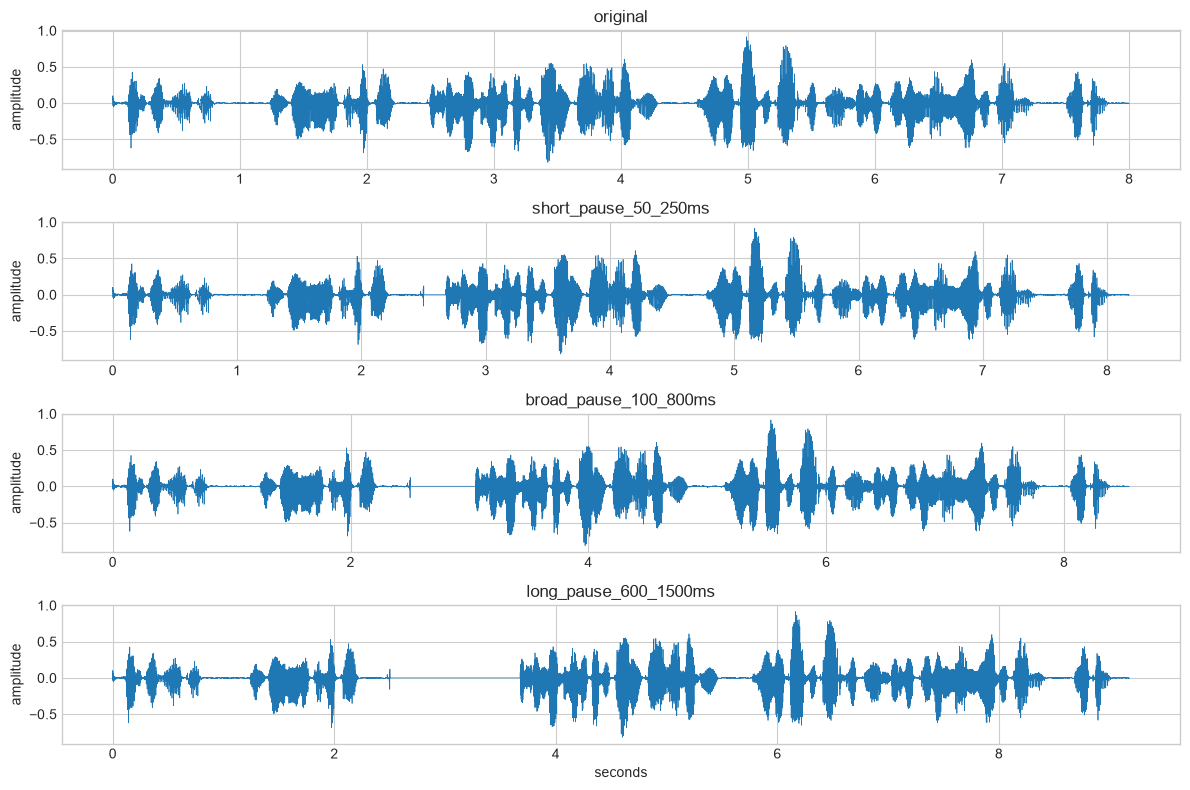

In [9]:
pause_variants = {"original": original}
for name, bounds in {
    "short_pause_50_250ms": (50, 250),
    "broad_pause_100_800ms": (100, 800),
    "long_pause_600_1500ms": (600, 1500),
}.items():
    random.seed(SEED)
    pause_variants[name] = insert_silence(original, sample_rate, *bounds, position="mid")

fig, axes = plt.subplots(len(pause_variants), 1, figsize=(12, 8), sharex=False)
for axis, (name, waveform) in zip(axes, pause_variants.items()):
    time = np.arange(len(waveform)) / sample_rate
    axis.plot(time, waveform, linewidth=0.5)
    axis.set(title=name, ylabel="amplitude")
axes[-1].set_xlabel("seconds")
plt.tight_layout()
plt.show()

### Hinglish filler injection

Production filler audio uses cached Hindi and Indian-English TTS voices with short crossfades. Injection occurs inside the clip and preserves the original endpoint. If cache is absent, run `scripts/prepare_data.py`; notebook does not silently call a network service.

In [10]:
filler_cache = cfg.DATA_DIR / "fillers"
cached_fillers = sorted(filler_cache.glob("*.wav"))
filler_variant = None
if cached_fillers:
    filler_bank = FillerBank(filler_cache)
    random.seed(SEED)
    filler_variant = inject_filler(original, sample_rate, filler_bank, position="mid")
    print(f"Used cached filler bank: {len(cached_fillers)} clips")
    print("Configured fillers:", ", ".join(cfg.HINGLISH_FILLERS))
else:
    print("No filler cache found. Run scripts/prepare_data.py to build it.")

Used cached filler bank: 76 clips
Configured fillers: um, uh, matlab, actually, tho, toh, yaar, bas, wait, ek second, haan, vo, voh, acha, umm, hmm, you know, like, so


### Speed, pitch, volume, and noise

In [11]:
noise_bank = load_noise_bank(cfg.DATA_DIR / "noise")
random.seed(SEED)
acoustic_variants = {
    "original": original,
    "speed_0.9_1.1x": speed_perturb(original, sample_rate),
    "pitch_plus_minus_2st": pitch_shift(original, sample_rate),
    "volume_plus_minus_6db": volume_perturb(original),
    "noise_5_20db_snr": add_background_noise(original, sample_rate, noise_bank),
}
if filler_variant is not None:
    acoustic_variants["internal_hinglish_filler"] = filler_variant

display(
    pl.DataFrame([audio_summary(name, waveform) for name, waveform in acoustic_variants.items()])
    .with_columns(pl.col("duration_s", "rms", "low_energy_fraction").round(4))
)

variant,duration_s,rms,low_energy_fraction,any_pause,internal_pause,trailing_pause
str,f64,f64,f64,bool,bool,bool
"""original""",8.0,0.0972,0.2403,true,true,true
"""speed_0.9_1.1x""",7.783,0.0658,0.1737,true,true,true
"""pitch_plus_minus_2st""",8.0,0.0636,0.169,true,true,true
"""volume_plus_minus_6db""",8.0,0.0712,0.2603,true,true,true
"""noise_5_20db_snr""",8.0,0.0983,0.0,false,false,false
"""internal_hinglish_filler""",9.1798,0.0944,0.2762,true,true,true


## 6. Hard-example creation

Hard mining attacks a duration shortcut:

- short complete clips (≤1.5 s) contradict “short means unfinished”;
- long incomplete clips (≥4 s) with a known filler flag contradict “long means finished.”

Candidates receive extra sampler weight instead of being duplicated on disk. Class mass is renormalized during training.

In [12]:
hard_indices = build_hard_negative_indices(train_df)
hard_df = (
    train_df.with_row_index("_row_index")
    .filter(pl.col("_row_index").is_in(hard_indices.tolist()))
    .drop("_row_index")
    .with_columns(
        pl.when(pl.col("endpoint_bool"))
        .then(pl.lit("short_complete"))
        .otherwise(pl.lit("long_incomplete_with_filler"))
        .alias("hard_case")
    )
)
hard_counts = hard_df.group_by("hard_case").len().sort("hard_case")
display(hard_counts)
display(
    hard_df.select("id", "language", "endpoint_bool", "duration_s", "midfiller", "endfiller", "hard_case")
    .sort("duration_s")
    .head(10)
)

hard_case,len
str,u32
"""long_incomplete_with_filler""",1707
"""short_complete""",17


id,language,endpoint_bool,duration_s,midfiller,endfiller,hard_case
str,str,bool,f64,bool,bool,str
"""016dfe8e-5a81-4b51-a3d8-df97fd…","""por""",true,0.36,true,false,"""short_complete"""
"""08397eaf-4540-4c10-8c64-2c7721…","""eng""",true,0.43025,false,false,"""short_complete"""
"""03bef195-96a1-431a-9ff1-f18aaa…","""eng""",true,0.6,false,false,"""short_complete"""
"""07d0b930-b293-49bb-b185-1a44aa…","""eng""",true,0.68,false,false,"""short_complete"""
"""0bcad118-7461-45eb-872b-6cf439…","""eng""",true,0.68,false,false,"""short_complete"""
"""08f8ce8f-81d6-411b-850f-f79f52…","""eng""",true,0.72,true,false,"""short_complete"""
"""0606c2b6-1f01-4425-9831-b63dcf…","""eng""",true,0.7209375,false,false,"""short_complete"""
"""01c83793-35dc-4026-98a7-37e625…","""eng""",true,0.76,false,false,"""short_complete"""
"""0de916a1-8458-48fd-b8b5-319c88…","""eng""",true,0.83725,false,false,"""short_complete"""


## 7. Train / validation / test strategy

The source schema lacks speaker and accent IDs, so a true speaker-disjoint split is impossible. Train/validation are stratified by `(language, endpoint_bool, source_dataset)` to preserve rare language/class/source combinations. The publisher's separate test repository remains the final held-out set.

Group-splitting by `source_dataset` was rejected because several tags are language-specific; it could remove whole languages from a small partition. If speaker IDs become available, group by speaker first, then stratify groups.

In [13]:
def split_record(name, frame):
    return {
        "split": name,
        "rows": frame.height,
        "complete": int(frame["endpoint_bool"].sum()),
        "incomplete": int((~frame["endpoint_bool"]).sum()),
        "hindi": int(frame.filter(pl.col("language") == "hin").height),
        "english": int(frame.filter(pl.col("language") == "eng").height),
        "source_tags": frame["source_dataset"].n_unique(),
    }

split_table = pl.DataFrame(
    [
        split_record("train", train_df),
        split_record("validation", val_df),
        split_record("publisher_test", test_df),
    ]
)
display(split_table)

train_ids, val_ids, test_ids = map(
    lambda frame: set(frame["id"].to_list()), (train_df, val_df, test_df)
)
overlap_table = pl.DataFrame(
    {
        "pair": ["train/validation", "train/test", "validation/test"],
        "overlap": [
            len(train_ids & val_ids),
            len(train_ids & test_ids),
            len(val_ids & test_ids),
        ],
    }
)
display(overlap_table)
assert overlap_table["overlap"].sum() == 0

split,rows,complete,incomplete,hindi,english,source_tags
str,i64,i64,i64,i64,i64,i64
"""train""",6613,3285,3328,634,3207,12
"""validation""",904,448,456,87,439,12
"""publisher_test""",4890,2461,2429,254,1507,12


pair,overlap
str,i64
"""train/validation""",0
"""train/test""",0
"""validation/test""",0


## 8. Before vs after comparison

Preparation does not claim to manufacture real Hinglish. It converts hidden assumptions into explicit, testable contracts.

In [14]:
strategy_comparison = pl.DataFrame(
    {
        "dimension": [
            "audio format",
            "endpoint labels",
            "filler metadata",
            "silence",
            "Hinglish coverage",
            "duration shortcut",
            "evaluation split",
            "augmentation storage",
        ],
        "before": [
            "dataset audio objects; decoding assumptions implicit",
            "publisher boolean",
            "nullable flags",
            "present but unmeasured",
            "single language tag; no code-switch label",
            "uncontrolled",
            "one source train split",
            "none",
        ],
        "after": [
            "validated mono 16 kHz float32; final 8 s retained",
            "same publisher label; no automatic flips",
            "boolean plus annotation-known provenance",
            "measured; retained; targeted training-only insertion",
            "Hindi/English sampling plus label-preserving filler augmentation",
            "short-complete and long-incomplete hard mining",
            "stratified train/validation plus separate publisher test",
            "online stochastic transforms; no duplicate WAV corpus",
        ],
    }
)
display(strategy_comparison)

variant_rows = [audio_summary(name, waveform) for name, waveform in pause_variants.items()]
variant_rows.extend(
    audio_summary(name, waveform)
    for name, waveform in acoustic_variants.items()
    if name != "original"
)
before_after_audio = (
    pl.DataFrame(variant_rows)
    .unique(subset=["variant"], keep="first", maintain_order=True)
    .with_columns(pl.col("duration_s", "rms", "low_energy_fraction").round(4))
)
display(before_after_audio)

dimension,before,after
str,str,str
"""audio format""","""dataset audio objects; decodin…","""validated mono 16 kHz float32;…"
"""endpoint labels""","""publisher boolean""","""same publisher label; no autom…"
"""filler metadata""","""nullable flags""","""boolean plus annotation-known …"
"""silence""","""present but unmeasured""","""measured; retained; targeted t…"
"""Hinglish coverage""","""single language tag; no code-s…","""Hindi/English sampling plus la…"
"""duration shortcut""","""uncontrolled""","""short-complete and long-incomp…"
"""evaluation split""","""one source train split""","""stratified train/validation pl…"
"""augmentation storage""","""none""","""online stochastic transforms; …"


variant,duration_s,rms,low_energy_fraction,any_pause,internal_pause,trailing_pause
str,f64,f64,f64,bool,bool,bool
"""original""",8.0,0.0972,0.2403,true,true,true
"""short_pause_50_250ms""",8.1779,0.0961,0.2537,true,true,true
"""broad_pause_100_800ms""",8.5476,0.094,0.286,true,true,true
"""long_pause_600_1500ms""",9.1754,0.0907,0.3362,true,true,true
"""speed_0.9_1.1x""",7.783,0.0658,0.1737,true,true,true
"""pitch_plus_minus_2st""",8.0,0.0636,0.169,true,true,true
"""volume_plus_minus_6db""",8.0,0.0712,0.2603,true,true,true
"""noise_5_20db_snr""",8.0,0.0983,0.0,false,false,false
"""internal_hinglish_filler""",9.1798,0.0944,0.2762,true,true,true


## Findings and decisions

- Classes are balanced, so accuracy is not distorted by a dominant label; FCR still matters because error costs are asymmetric.
- Pauses occur in both complete and incomplete clips. Preserve them and avoid silence-only rules.
- Filler flags are useful slices but incomplete prevalence estimates because source annotations can be unknown.
- Label-preserving filler injection is safer than converting every filler into an incomplete example.
- Hard-example counts are highly asymmetric, so hard mining is a false-complete-focused curriculum—not a balanced benchmark.
- Current split is auditable and ID-disjoint, but not speaker-disjoint.
- Synthetic augmentations improve coverage, not authenticity. Human Hinglish remains the highest-value data addition.

See `docs/01_data_preparation_approach.md` for full rationale and `docs/03_ablation_and_insights.md` for measured downstream effects.

## Next steps

1. Collect consented human Hinglish with speaker IDs, real code-switch transcripts, filler identity, and pause boundaries.
2. Build a fixed speaker-disjoint challenge set before more model tuning.
3. Manually review high-confidence validation errors and replace heuristic-only hard mining with confirmed cases.
4. Add licensed Indian street, office, phone, and household noise.
5. Repeat finalists across seeds and calibrate threshold on validation FCR with a recall floor.